# Đánh giá tính khả thi dataset cho bài toán Next-Time Prediction

Notebook này đánh giá tính khả thi của các dataset cho bài toán nghiên cứu:

> Với chuỗi lịch sử tương tác có dấu thời gian của một người dùng, liệu ta có thể dự đoán khoảng thời gian cho đến sự kiện tiếp theo của người dùng đó không?

Mục tiêu giám sát chung của bài toán là:

```text
delta_t = next_timestamp - current_timestamp
```

Trong notebook này, `delta_t` được biểu diễn bằng cột:

```text
delta_t_seconds
```

Tức là mỗi dòng sau khi tạo target sẽ biểu diễn một event hiện tại của user và event kế tiếp ngay sau nó trong chuỗi thời gian. Từ hai thời điểm này, ta tính được khoảng thời gian đến event tiếp theo.

Notebook này **không phải EDA tổng quát** và **không huấn luyện mô hình**. Trọng tâm của notebook là kiểm tra:

* Dataset có tạo được mẫu `next-time prediction` hợp lệ hay không.
* Người dùng có đủ chuỗi sự kiện để tạo `next_timestamp` hay không.
* Tín hiệu `timestamp` có hợp lệ và có thể dùng được hay không.
* Phân phối của `delta_t_seconds` có quá lệch hay không.
* Notebook mô hình tiếp theo nên bắt đầu bằng regression trên `delta_t_seconds`/`log1p(delta_t_seconds)` hay classification bằng `time_bucket`.

---

## Các dataset được sử dụng

Notebook chỉ xét ba dataset:

1. **Last.fm 1K**
2. **RetailRocket**
3. **Taobao UserBehavior**

Ba dataset này được chọn vì đều có chung cấu trúc cốt lõi cho bài toán next-time prediction:

```text
user_id + item/event + timestamp
```

Nói cách khác, cả ba dataset đều có thể được sắp xếp theo `user_id` và `timestamp` để tạo chuỗi sự kiện theo thời gian cho từng người dùng.

**MIND không được đưa vào notebook này.** Lý do là MIND phù hợp hơn với bài toán news click prediction/ranking, trong khi notebook này tập trung vào dự đoán thời gian đến sự kiện tiếp theo từ chuỗi event của người dùng.

---

## Cột ban đầu của từng dataset

Trước khi chuẩn hóa, mỗi dataset có schema gốc khác nhau.

| Dataset                 | Số cột gốc | Các cột gốc                                                                  | Ý nghĩa chính                                                       |
| ----------------------- | ---------: | ---------------------------------------------------------------------------- | ------------------------------------------------------------------- |
| **Last.fm 1K**          |          6 | `user_id`, `timestamp`, `artist_id`, `artist_name`, `track_id`, `track_name` | Mỗi dòng là một lượt nghe nhạc của user                             |
| **RetailRocket**        |          4 | `timestamp`, `visitorid`, `event`, `itemid`                                  | Mỗi dòng là một hành vi của visitor trên website thương mại điện tử |
| **Taobao UserBehavior** |          5 | `user_id`, `item_id`, `category_id`, `behavior_type`, `timestamp`            | Mỗi dòng là một hành vi mua sắm của user trên item/category         |

Các cột này không giống nhau về tên gọi, nhưng đều chứa ba loại thông tin quan trọng:

```text
người dùng
đối tượng tương tác
thời điểm tương tác
```

Đây là điều kiện cần để tạo bài toán `next-time prediction`.

---

## Mapping cột gốc sang schema chung

Để xử lý thống nhất, notebook chuẩn hóa các dataset về cùng một schema sự kiện chung:

```text
user_id
item_id
category_id
event_type
timestamp
```

Bảng mapping cụ thể như sau:

| Dataset          | Cột gốc                     | Cột sau chuẩn hóa | Giải thích                                                                                              |
| ---------------- | --------------------------- | ----------------- | ------------------------------------------------------------------------------------------------------- |
| **Last.fm**      | `user_id`                   | `user_id`         | Định danh người nghe nhạc                                                                               |
| **Last.fm**      | `track_id` hoặc `artist_id` | `item_id`         | Bài hát hoặc nghệ sĩ được nghe; ưu tiên `track_id` nếu đủ dữ liệu, nếu thiếu nhiều thì dùng `artist_id` |
| **Last.fm**      | Không có                    | `category_id`     | Gán `NA` vì Last.fm không có category theo schema này                                                   |
| **Last.fm**      | Không có                    | `event_type`      | Gán cố định là `listen`                                                                                 |
| **Last.fm**      | `timestamp`                 | `timestamp`       | Thời điểm user nghe nhạc                                                                                |
| **RetailRocket** | `visitorid`                 | `user_id`         | Định danh visitor/người dùng                                                                            |
| **RetailRocket** | `itemid`                    | `item_id`         | Sản phẩm mà user tương tác                                                                              |
| **RetailRocket** | Không có                    | `category_id`     | Gán `NA` nếu chỉ dùng file event chính                                                                  |
| **RetailRocket** | `event`                     | `event_type`      | Loại hành vi, ví dụ `view`, `addtocart`, `transaction`                                                  |
| **RetailRocket** | `timestamp`                 | `timestamp`       | Thời điểm xảy ra event                                                                                  |
| **Taobao**       | `user_id`                   | `user_id`         | Định danh người dùng                                                                                    |
| **Taobao**       | `item_id`                   | `item_id`         | Sản phẩm mà user tương tác                                                                              |
| **Taobao**       | `category_id`               | `category_id`     | Danh mục của sản phẩm                                                                                   |
| **Taobao**       | `behavior_type`             | `event_type`      | Loại hành vi, ví dụ `pv`, `cart`, `fav`, `buy`                                                          |
| **Taobao**       | `timestamp`                 | `timestamp`       | Thời điểm xảy ra event                                                                                  |

Sau bước chuẩn hóa, cả ba dataset có thể được xử lý bằng cùng một pipeline.

---

## Schema sau khi chuẩn hóa

Sau khi chuẩn hóa, mỗi dòng dữ liệu biểu diễn một event hiện tại:

```text
dataset
data_scope
user_id
item_id
category_id
event_type
timestamp
```

Ý nghĩa các cột:

| Cột           | Ý nghĩa                                                                                                         | Có dùng trong bài toán cuối không?                                        |
| ------------- | --------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------- |
| `dataset`     | Tên dataset gốc, ví dụ `Last.fm`, `RetailRocket`, `Taobao`                                                      | Không dùng làm feature chính; dùng để phân biệt nguồn dữ liệu khi so sánh |
| `data_scope`  | Phạm vi dữ liệu, ví dụ `full`, `row_sample`, `user_sample`, `full_chunk`                                        | Không dùng làm feature; dùng để tránh nhầm lẫn giữa full data và sample   |
| `user_id`     | Định danh người dùng                                                                                            | Có, dùng để gom event thành chuỗi theo từng user                          |
| `item_id`     | Đối tượng được tương tác, ví dụ bài hát, nghệ sĩ hoặc sản phẩm                                                  | Có, có thể dùng làm feature                                               |
| `category_id` | Danh mục của item, chủ yếu có trong Taobao                                                                      | Có nếu dataset có; với Last.fm và RetailRocket có thể để `NA`             |
| `event_type`  | Loại hành vi tại event hiện tại, ví dụ `listen`, `view`, `addtocart`, `transaction`, `pv`, `cart`, `fav`, `buy` | Có, là feature quan trọng mô tả hành vi hiện tại                          |
| `timestamp`   | Thời điểm xảy ra event hiện tại                                                                                 | Có, dùng để sắp xếp chuỗi và tạo target                                   |

---

## Schema sau khi tạo target next-time

Sau khi sắp xếp event theo `user_id` và `timestamp`, notebook tạo thêm thông tin của event kế tiếp:

```text
next_item_id
next_category_id
next_event_type
next_timestamp
delta_t_seconds
time_bucket
```

Schema đầy đủ sau khi tạo target được khuyến nghị là:

```text
dataset
data_scope
user_id
item_id
category_id
event_type
timestamp
next_item_id
next_category_id
next_event_type
next_timestamp
delta_t_seconds
time_bucket
```

Ý nghĩa các cột sau khi tạo target:

| Cột                | Ý nghĩa                                                                               | Có dùng trong bài toán cuối không?   | Vai trò                                                                   |
| ------------------ | ------------------------------------------------------------------------------------- | ------------------------------------ | ------------------------------------------------------------------------- |
| `next_item_id`     | Item ở event kế tiếp của cùng user                                                    | Không dùng nếu chỉ dự đoán thời gian | Có thể dùng cho bài toán phụ như next-item prediction                     |
| `next_category_id` | Category ở event kế tiếp                                                              | Không dùng nếu chỉ dự đoán thời gian | Có thể dùng cho bài toán phụ như next-category prediction                 |
| `next_event_type`  | Loại hành vi ở event kế tiếp                                                          | Không phải target chính              | Có thể dùng để phân tích transition hoặc làm target phụ                   |
| `next_timestamp`   | Thời điểm xảy ra event kế tiếp                                                        | Không dùng làm feature               | Chỉ dùng để tính `delta_t_seconds`; không đưa vào input vì sẽ gây leakage |
| `delta_t_seconds`  | Khoảng thời gian từ event hiện tại đến event kế tiếp, tính bằng giây                  | Có                                   | Target chính nếu bài toán được mô hình hóa dưới dạng regression           |
| `time_bucket`      | Nhóm thời gian rời rạc hóa từ `delta_t_seconds`, ví dụ `<1h`, `1h-1d`, `1d-7d`, `>7d` | Có                                   | Target chính nếu bài toán được mô hình hóa dưới dạng classification       |

---

## Feature và target trong bài toán cuối

Trong bài toán cuối, các cột có thể được chia thành ba nhóm.

### Nhóm feature đầu vào

Các cột có thể dùng làm đầu vào cho model:

```text
user_id
item_id
category_id
event_type
timestamp
```

Tuy nhiên, `timestamp` thường không nên đưa trực tiếp vào model dưới dạng datetime gốc. Thay vào đó, nên chuyển thành các đặc trưng thời gian như:

```text
hour_of_day
day_of_week
is_weekend
time_since_previous_event
```

### Nhóm target

Có hai cách mô hình hóa bài toán:

```text
delta_t_seconds
```

được dùng nếu xem bài toán là regression, tức dự đoán trực tiếp khoảng thời gian đến event tiếp theo.

Hoặc:

```text
time_bucket
```

được dùng nếu xem bài toán là classification, tức dự đoán event tiếp theo sẽ xảy ra trong nhóm thời gian nào.

Trong notebook này, `delta_t_seconds` là target gốc, còn `time_bucket` là target được rời rạc hóa để giảm độ khó khi phân phối thời gian bị lệch mạnh.

### Nhóm không dùng làm feature vì chứa thông tin tương lai

Các cột sau được tạo từ event kế tiếp nên không được đưa trực tiếp vào feature khi train model dự đoán thời gian:

```text
next_item_id
next_category_id
next_event_type
next_timestamp
```

Đặc biệt, `next_timestamp` chỉ được dùng để tính `delta_t_seconds`. Nếu đưa `next_timestamp` vào input, model sẽ bị rò rỉ thông tin tương lai.

---

## Kết luận

Ba dataset Last.fm 1K, RetailRocket và Taobao UserBehavior đều phù hợp với bài toán next-time prediction vì có thể chuẩn hóa về cùng dạng dữ liệu event theo thời gian ở cấp user. Sau khi chuẩn hóa, mỗi dataset đều có thể tạo `next_timestamp`, từ đó sinh ra target `delta_t_seconds`.

Last.fm đại diện cho hành vi nghe nhạc, RetailRocket đại diện cho hành vi thương mại điện tử ở quy mô vừa, còn Taobao đại diện cho dữ liệu thương mại điện tử lớn với nhiều loại hành vi. Sự kết hợp này giúp đánh giá bài toán next-time prediction trên nhiều ngữ cảnh khác nhau nhưng vẫn giữ cùng một formulation.

## 1. Cấu hình và thư viện

Notebook tự phát hiện thư mục gốc của project bằng cách đi ngược từ thư mục hiện tại cho đến khi tìm thấy thư mục `data`. Nhờ vậy notebook có thể chạy ổn định khi mở từ project root hoặc từ thư mục `notebooks/`.


In [1]:
from pathlib import Path
from collections import Counter
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "data").exists():
            return p
    return start


BASE_DIR = find_project_root()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs" / "next_time_feasibility"
FIGURE_DIR = OUTPUT_DIR / "figures"

LASTFM_PATH = DATA_DIR / "lastfm" / "userid-timestamp-artid-artname-traid-traname.tsv"
RETAILROCKET_PATH = DATA_DIR / "retailrocket" / "events.csv"
TAOBAO_PATH = DATA_DIR / "taobao" / "UserBehavior.csv"

RANDOM_SEED = 42

RUN_FULL_LASTFM = True
RUN_FULL_RETAILROCKET = True

# Taobao is large. Use careful profiling by default; enable fast mode only for quick smoke tests.
TAOBAO_FAST_MODE = False
TAOBAO_FULL_CHUNK_PROFILE = True
TAOBAO_CHUNK_SIZE = 1_000_000

TAOBAO_SEQUENCE_MODE = "user_sample"  # options: "row_sample", "user_sample"
TAOBAO_ROW_SAMPLE_NROWS = 1_000_000
TAOBAO_USER_SAMPLE_N_USERS = 50_000

TIME_BUCKETS_SECONDS = [
    0,
    3600,
    86400,
    604800,
    float("inf"),
]

TIME_BUCKET_LABELS = [
    "<1h",
    "1h-1d",
    "1d-7d",
    ">7d",
]


## 2. Hàm tiện ích

Các hàm trong phần này tạo thư mục đầu ra, lưu bảng kết quả, tìm đường dẫn dataset trong cấu trúc project hiện tại, và hiển thị nhanh thông tin sau khi load dữ liệu.


In [2]:
def ensure_output_dirs():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_table(df, filename):
    ensure_output_dirs()
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved: {path}")
    return path


def resolve_dataset_path(path, fallback_paths=None):
    """Use the requested path when present; otherwise try known local raw-data locations."""
    path = Path(path)
    if path.exists():
        return path
    for fallback in fallback_paths or []:
        fallback = Path(fallback)
        if fallback.exists():
            print(f"Using fallback path for {path.name}: {fallback}")
            return fallback
    raise FileNotFoundError(f"Could not find {path}. Tried fallbacks: {fallback_paths}")


def display_dataset_preview(df, name):
    print(f"{name} shape: {df.shape}")
    print(f"{name} columns: {list(df.columns)}")
    print(f"{name} data_scope: {df['data_scope'].iloc[0] if len(df) else 'empty'}")
    if "timestamp" in df.columns and len(df):
        print(f"{name} timestamp range: {df['timestamp'].min()} -> {df['timestamp'].max()}")
    display(df.head())


ensure_output_dirs()


## 3. Hàm chuẩn hóa dataset

Mỗi dataset được đưa về schema chung gồm `user_id`, `item_id`, `category_id`, `event_type`, và `timestamp`. Với Last.fm, một số dòng có thể thiếu `track_id`; vì vậy notebook ưu tiên dùng `track_id` nếu tỷ lệ không thiếu đủ cao, ngược lại sẽ fallback sang `artist_id` để giữ được item-level signal ở mức nghệ sĩ. `category_id` chủ yếu có trong Taobao; với Last.fm và RetailRocket, cột này được giữ là `NA` để các dataset có cùng schema.


In [3]:
def standardize_lastfm(path, sample_n=None):
    path = resolve_dataset_path(
        path,
        [DATA_DIR / "raw" / "lastfm-dataset-1K" / "userid-timestamp-artid-artname-traid-traname.tsv"],
    )
    names = ["user_id", "timestamp", "artist_id", "artist_name", "track_id", "track_name"]
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=names,
        usecols=["user_id", "timestamp", "artist_id", "track_id"],
        nrows=sample_n,
        dtype={"user_id": "string", "artist_id": "string", "track_id": "string"},
        encoding="utf-8",
        low_memory=False,
    )
    for col in ["artist_id", "track_id"]:
        if col in df.columns:
            df[col] = df[col].str.strip().replace(["", "nan", "None", "NULL", "NaN"], pd.NA)

    track_non_null_rate = df["track_id"].notna().mean()
    item_source = "track_id" if track_non_null_rate >= 0.50 else "artist_id"
    df["item_id"] = df[item_source]
    df["category_id"] = pd.NA
    df["event_type"] = "listen"
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df["dataset"] = "Last.fm"
    df["data_scope"] = "full" if sample_n is None else "row_sample"
    return df[["dataset", "data_scope", "user_id", "item_id", "category_id", "event_type", "timestamp"]]


def standardize_retailrocket(path, sample_n=None):
    path = resolve_dataset_path(path, [DATA_DIR / "raw" / "RetailRocket" / "events.csv"])
    df = pd.read_csv(
        path,
        nrows=sample_n,
        usecols=["timestamp", "visitorid", "event", "itemid"],
        dtype={"visitorid": "string", "event": "string", "itemid": "string"},
        low_memory=False,
    )
    df = df.rename(columns={"visitorid": "user_id", "itemid": "item_id", "event": "event_type"})
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", errors="coerce", utc=True)
    df["category_id"] = pd.NA
    df["dataset"] = "RetailRocket"
    df["data_scope"] = "full" if sample_n is None else "row_sample"
    return df[["dataset", "data_scope", "user_id", "item_id", "category_id", "event_type", "timestamp"]]


def _read_taobao_chunks(path, chunksize, nrows=None):
    names = ["user_id", "item_id", "category_id", "behavior_type", "timestamp"]
    return pd.read_csv(
        path,
        header=None,
        names=names,
        nrows=nrows,
        chunksize=chunksize,
        dtype={"user_id": "int64", "item_id": "int64", "category_id": "int64", "behavior_type": "string", "timestamp": "int64"},
    )


def _finalize_taobao(df, data_scope):
    df = df.rename(columns={"behavior_type": "event_type"})
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce", utc=True)
    df["dataset"] = "Taobao"
    df["data_scope"] = data_scope
    return df[["dataset", "data_scope", "user_id", "item_id", "category_id", "event_type", "timestamp"]]


def standardize_taobao_sample(
    path,
    mode="user_sample",
    row_sample_n=1_000_000,
    user_sample_n=50_000,
    random_seed=42,
):
    path = resolve_dataset_path(path, [DATA_DIR / "raw" / "TaoBao" / "UserBehavior.csv"])
    rng = np.random.default_rng(random_seed)

    if mode == "row_sample":
        df = pd.read_csv(
            path,
            header=None,
            names=["user_id", "item_id", "category_id", "behavior_type", "timestamp"],
            nrows=row_sample_n,
            dtype={"user_id": "int64", "item_id": "int64", "category_id": "int64", "behavior_type": "string", "timestamp": "int64"},
        )
        return _finalize_taobao(df, "row_sample")

    if mode != "user_sample":
        raise ValueError("mode must be either 'row_sample' or 'user_sample'")

    # Exact user IDs are collected first; approximate sampling can replace this on constrained machines.
    users = set()
    for chunk in _read_taobao_chunks(path, chunksize=TAOBAO_CHUNK_SIZE):
        users.update(chunk["user_id"].dropna().unique().tolist())
        del chunk
        gc.collect()

    users = np.array(list(users))
    sample_size = min(user_sample_n, len(users))
    selected_users = set(rng.choice(users, size=sample_size, replace=False).tolist())
    print(f"Selected {len(selected_users):,} Taobao users from {len(users):,} unique users.")

    selected_chunks = []
    for chunk in _read_taobao_chunks(path, chunksize=TAOBAO_CHUNK_SIZE):
        keep = chunk[chunk["user_id"].isin(selected_users)]
        if len(keep):
            selected_chunks.append(keep.copy())
        del chunk, keep
        gc.collect()

    if not selected_chunks:
        return _finalize_taobao(pd.DataFrame(columns=["user_id", "item_id", "category_id", "behavior_type", "timestamp"]), "user_sample")
    df = pd.concat(selected_chunks, ignore_index=True)
    del selected_chunks
    gc.collect()
    return _finalize_taobao(df, "user_sample")


## 4. Profile toàn bộ Taobao bằng chunk

Taobao có kích thước lớn, nên profile toàn bộ dataset được thực hiện theo chunk thay vì load toàn bộ vào RAM. Phần này thu thập số dòng, số user/item/category, phân phối `event_type`, khoảng thời gian, và tỷ lệ thiếu dữ liệu ở mức toàn bộ dataset.


In [4]:
def profile_taobao_full_chunks(path, chunk_size=1_000_000):
    path = resolve_dataset_path(path, [DATA_DIR / "raw" / "TaoBao" / "UserBehavior.csv"])
    total_rows = 0
    users = set()
    items = set()
    categories = set()
    event_counts = Counter()
    timestamp_min = None
    timestamp_max = None
    missing_timestamp_count = 0
    missing_user_count = 0
    missing_item_count = 0

    # Exact sets are attempted because Taobao UserBehavior is usually manageable on a research workstation.
    # For extremely constrained memory, approximate unique counting could be substituted later.
    for chunk in _read_taobao_chunks(path, chunksize=chunk_size):
        total_rows += len(chunk)
        missing_timestamp_count += chunk["timestamp"].isna().sum()
        missing_user_count += chunk["user_id"].isna().sum()
        missing_item_count += chunk["item_id"].isna().sum()
        users.update(chunk["user_id"].dropna().unique().tolist())
        items.update(chunk["item_id"].dropna().unique().tolist())
        categories.update(chunk["category_id"].dropna().unique().tolist())
        event_counts.update(chunk["behavior_type"].dropna().astype(str).tolist())
        chunk_ts = pd.to_datetime(chunk["timestamp"], unit="s", errors="coerce", utc=True)
        cmin = chunk_ts.min()
        cmax = chunk_ts.max()
        timestamp_min = cmin if timestamp_min is None or cmin < timestamp_min else timestamp_min
        timestamp_max = cmax if timestamp_max is None or cmax > timestamp_max else timestamp_max
        del chunk, chunk_ts
        gc.collect()

    span_days = (timestamp_max - timestamp_min).total_seconds() / 86400 if timestamp_min is not None and timestamp_max is not None else np.nan
    taobao_full_basic_stats = pd.DataFrame([{
        "dataset": "Taobao",
        "data_scope": "full_chunk",
        "num_rows": total_rows,
        "num_users": len(users),
        "num_items": len(items),
        "num_categories": len(categories),
        "num_event_types": len(event_counts),
        "time_min": timestamp_min,
        "time_max": timestamp_max,
        "time_span_days": span_days,
        "missing_user_rate": missing_user_count / total_rows if total_rows else np.nan,
        "missing_item_rate": missing_item_count / total_rows if total_rows else np.nan,
        "missing_timestamp_rate": missing_timestamp_count / total_rows if total_rows else np.nan,
        "duplicate_rate": np.nan,
    }])

    total_events = sum(event_counts.values())
    taobao_full_event_distribution = pd.DataFrame([
        {
            "dataset": "Taobao",
            "data_scope": "full_chunk",
            "event_type": event_type,
            "count": count,
            "percentage": count / total_events * 100 if total_events else np.nan,
        }
        for event_type, count in event_counts.most_common()
    ])
    return taobao_full_basic_stats, taobao_full_event_distribution


## 5. Hàm đánh giá feasibility và tạo mục tiêu

Các hàm trong phần này tính thống kê cơ bản, độ dài chuỗi theo user, tạo `next_timestamp`, tạo mục tiêu `delta_t_seconds`, rời rạc hóa thành `time_bucket`, và đo phân phối của mục tiêu.

Khi tạo target, sự kiện được sắp xếp ổn định theo `user_id` và `timestamp`. Những dòng không có sự kiện tiếp theo hoặc có `delta_t_seconds <= 0` bị loại bỏ vì chúng không tạo được mẫu học hợp lệ cho bài toán dự đoán thời gian đến sự kiện tiếp theo. Thống kê các dòng bị loại được lưu lại để minh bạch hóa mức hao hụt dữ liệu.


In [5]:
def compute_basic_stats(df, dataset_name, data_scope):
    n = len(df)
    time_min = df["timestamp"].min() if n else pd.NaT
    time_max = df["timestamp"].max() if n else pd.NaT
    span_days = (time_max - time_min).total_seconds() / 86400 if pd.notna(time_min) and pd.notna(time_max) else np.nan
    return pd.DataFrame([{
        "dataset": dataset_name,
        "data_scope": data_scope,
        "num_rows": n,
        "num_users": df["user_id"].nunique(dropna=True),
        "num_items": df["item_id"].nunique(dropna=True),
        "num_event_types": df["event_type"].nunique(dropna=True),
        "time_min": time_min,
        "time_max": time_max,
        "time_span_days": span_days,
        "missing_user_rate": df["user_id"].isna().mean() if n else np.nan,
        "missing_item_rate": df["item_id"].isna().mean() if n else np.nan,
        "missing_timestamp_rate": df["timestamp"].isna().mean() if n else np.nan,
        "duplicate_rate": df.duplicated().mean() if n else np.nan,
    }])


def compute_sequence_stats(df, dataset_name, data_scope):
    # Users with 1 event cannot create next-time targets.
    # Users with at least 2 events can create at least one next-time sample.
    # Users with longer histories are better for sequence modeling.
    counts = df.groupby("user_id", dropna=True).size()
    num_users = len(counts)
    return pd.DataFrame([{
        "dataset": dataset_name,
        "data_scope": data_scope,
        "num_users": num_users,
        "mean_interactions_per_user": counts.mean() if num_users else np.nan,
        "median_interactions_per_user": counts.median() if num_users else np.nan,
        "p75_interactions_per_user": counts.quantile(0.75) if num_users else np.nan,
        "p90_interactions_per_user": counts.quantile(0.90) if num_users else np.nan,
        "p95_interactions_per_user": counts.quantile(0.95) if num_users else np.nan,
        "max_interactions_per_user": counts.max() if num_users else np.nan,
        "users_with_2plus": (counts >= 2).sum(),
        "users_with_5plus": (counts >= 5).sum(),
        "users_with_10plus": (counts >= 10).sum(),
        "users_with_20plus": (counts >= 20).sum(),
        "pct_users_with_2plus": (counts >= 2).mean() * 100 if num_users else np.nan,
        "pct_users_with_5plus": (counts >= 5).mean() * 100 if num_users else np.nan,
        "pct_users_with_10plus": (counts >= 10).mean() * 100 if num_users else np.nan,
        "pct_users_with_20plus": (counts >= 20).mean() * 100 if num_users else np.nan,
    }])



def create_next_time_targets(df):
    dataset_name = df["dataset"].iloc[0] if "dataset" in df.columns and len(df) else "Unknown"
    data_scope = df["data_scope"].iloc[0] if "data_scope" in df.columns and len(df) else "unknown"

    work = df.dropna(subset=["user_id", "timestamp"]).copy()
    if "category_id" not in work.columns:
        work["category_id"] = pd.NA
    original_rows = len(work)

    work = work.sort_values(["user_id", "timestamp"], kind="mergesort")
    grouped = work.groupby("user_id", sort=False)
    work["next_timestamp"] = grouped["timestamp"].shift(-1)
    work["next_item_id"] = grouped["item_id"].shift(-1)
    work["next_category_id"] = grouped["category_id"].shift(-1)
    work["next_event_type"] = grouped["event_type"].shift(-1)
    work["delta_t_seconds"] = (work["next_timestamp"] - work["timestamp"]).dt.total_seconds()

    candidate_next_rows = int(work["next_timestamp"].notna().sum())
    missing_next_timestamp_rows = int(work["next_timestamp"].isna().sum())
    zero_or_negative_delta_rows = int((work["delta_t_seconds"] <= 0).sum())

    valid_mask = work["next_timestamp"].notna() & work["delta_t_seconds"].notna() & (work["delta_t_seconds"] > 0)
    valid_next_time_rows = int(valid_mask.sum())

    summary = {
        "dataset": dataset_name,
        "data_scope": data_scope,
        "original_rows": original_rows,
        "candidate_next_rows": candidate_next_rows,
        "missing_next_timestamp_rows": missing_next_timestamp_rows,
        "zero_or_negative_delta_rows": zero_or_negative_delta_rows,
        "valid_next_time_rows": valid_next_time_rows,
        "valid_next_time_rate": valid_next_time_rows / original_rows if original_rows else 0,
    }

    keep_cols = [
        "dataset", "data_scope", "user_id", "item_id", "category_id", "event_type", "timestamp",
        "next_item_id", "next_category_id", "next_event_type", "next_timestamp", "delta_t_seconds",
    ]
    target_df = work.loc[valid_mask, keep_cols].reset_index(drop=True)
    return target_df, summary

def add_time_bucket(target_df, bins, labels):
    target_df = target_df.copy()
    target_df["time_bucket"] = pd.cut(
        target_df["delta_t_seconds"],
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True,
    )
    return target_df


def compute_delta_stats(target_df, dataset_name, data_scope):
    s = target_df["delta_t_seconds"].dropna()
    return pd.DataFrame([{
        "dataset": dataset_name,
        "data_scope": data_scope,
        "num_next_time_samples": len(s),
        "delta_t_min": s.min() if len(s) else np.nan,
        "delta_t_median": s.median() if len(s) else np.nan,
        "delta_t_mean": s.mean() if len(s) else np.nan,
        "delta_t_p75": s.quantile(0.75) if len(s) else np.nan,
        "delta_t_p90": s.quantile(0.90) if len(s) else np.nan,
        "delta_t_p95": s.quantile(0.95) if len(s) else np.nan,
        "delta_t_p99": s.quantile(0.99) if len(s) else np.nan,
        "delta_t_max": s.max() if len(s) else np.nan,
        "delta_t_median_hours": s.median() / 3600 if len(s) else np.nan,
        "delta_t_p90_hours": s.quantile(0.90) / 3600 if len(s) else np.nan,
        "delta_t_p95_hours": s.quantile(0.95) / 3600 if len(s) else np.nan,
    }])



def recommend_target_type(row):
    median = max(row["delta_t_median"], 1)
    ratio = row["delta_t_p95"] / median
    if ratio >= 100:
        return "time_bucket_classification"
    return "log_delta_regression"


## 6. Hàm vẽ biểu đồ, phân tích event, và kiểm tra split

Phần này dùng matplotlib để vẽ phân phối `log1p(delta_t_seconds)` và phân phối `time_bucket`, đồng thời phân tích phân phối `event_type`, chuyển tiếp giữa các loại sự kiện, và feasibility của split theo thời gian.


In [6]:
def plot_log_delta_distribution(target_df, dataset_name, output_path):
    ensure_output_dirs()
    fig, ax = plt.subplots(figsize=(8, 5))
    values = np.log1p(target_df["delta_t_seconds"].dropna())
    ax.hist(values, bins=60)
    ax.set_title(f"{dataset_name}: log1p(delta_t_seconds)")
    ax.set_xlabel("log1p(delta_t_seconds)")
    ax.set_ylabel("Count")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()
    return output_path


def plot_time_bucket_distribution(target_df, dataset_name, output_path):
    ensure_output_dirs()
    counts = target_df["time_bucket"].value_counts().reindex(TIME_BUCKET_LABELS, fill_value=0)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"{dataset_name}: time bucket distribution")
    ax.set_xlabel("Time bucket")
    ax.set_ylabel("Count")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()
    return output_path


def compute_event_distribution(df, dataset_name, data_scope):
    counts = df["event_type"].value_counts(dropna=False).reset_index()
    counts.columns = ["event_type", "count"]
    counts.insert(0, "data_scope", data_scope)
    counts.insert(0, "dataset", dataset_name)
    total = counts["count"].sum()
    counts["percentage"] = counts["count"] / total * 100 if total else np.nan
    return counts


def compute_transition_distribution(target_df, dataset_name, data_scope, top_n=20):
    counts = (
        target_df.groupby(["event_type", "next_event_type"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    counts.insert(0, "data_scope", data_scope)
    counts.insert(0, "dataset", dataset_name)
    total = len(target_df)
    counts["percentage"] = counts["count"] / total * 100 if total else np.nan
    return counts


def leave_last_one_split(target_df):
    work = target_df.sort_values(["user_id", "timestamp"], kind="mergesort").copy()
    target_counts = work.groupby("user_id").size()
    valid_users = target_counts[target_counts >= 2].index
    work = work[work["user_id"].isin(valid_users)].copy()
    ranks = work.groupby("user_id").cumcount(ascending=False)
    test_df = work[ranks == 0].copy()
    train_df = work[ranks > 0].copy()
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


def compute_split_stats(train_df, test_df, dataset_name, data_scope):
    train_users = set(train_df["user_id"].dropna().unique())
    test_users = set(test_df["user_id"].dropna().unique())
    train_items = set(train_df["item_id"].dropna().unique()) | set(train_df["next_item_id"].dropna().unique())
    test_items = set(test_df["item_id"].dropna().unique()) | set(test_df["next_item_id"].dropna().unique())
    seen_test_users = len(test_users & train_users)
    cold_items = len(test_items - train_items)
    return pd.DataFrame([{
        "dataset": dataset_name,
        "data_scope": data_scope,
        "train_samples": len(train_df),
        "test_samples": len(test_df),
        "train_users": len(train_users),
        "test_users": len(test_users),
        "test_users_seen_in_train": seen_test_users,
        "pct_test_users_seen_in_train": seen_test_users / len(test_users) * 100 if test_users else np.nan,
        "cold_start_item_rate": cold_items / len(test_items) * 100 if test_items else np.nan,
    }])


## 7. Load và chuẩn hóa dataset

Phạm vi phân tích được giữ rõ ràng bằng `data_scope`:

- Last.fm: phân tích full data.
- RetailRocket: phân tích full data.
- Taobao: profile toàn bộ bằng chunk; phân tích sequence-level trên subset do kích thước lớn.

Mọi bảng kết quả đều giữ `data_scope` để tránh trộn lẫn kết quả full và sampled.

**Cảnh báo runtime cho Taobao:** Taobao sẽ được đọc nhiều lần: một lần để profile toàn bộ bằng chunk, một lần để lấy danh sách user, và một lần để trích xuất subset theo user. Quá trình này có thể tốn thời gian trên máy cá nhân.


In [7]:
lastfm_df = standardize_lastfm(LASTFM_PATH, sample_n=None if RUN_FULL_LASTFM else 1_000_000)
display_dataset_preview(lastfm_df, "Last.fm")

retailrocket_df = standardize_retailrocket(RETAILROCKET_PATH, sample_n=None if RUN_FULL_RETAILROCKET else 1_000_000)
display_dataset_preview(retailrocket_df, "RetailRocket")

if TAOBAO_FAST_MODE:
    print("TAOBAO_FAST_MODE=True: bỏ qua full chunk profile và dùng row_sample để kiểm tra nhanh.")
    taobao_full_basic_stats = pd.DataFrame()
    taobao_full_event_distribution = pd.DataFrame()
    taobao_sequence_mode = "row_sample"
else:
    print("Taobao sẽ được đọc nhiều lần: một lần để profile toàn bộ bằng chunk, một lần để lấy danh sách user, và một lần để trích xuất subset theo user. Quá trình này có thể tốn thời gian trên máy cá nhân.")
    taobao_sequence_mode = TAOBAO_SEQUENCE_MODE
    if TAOBAO_FULL_CHUNK_PROFILE:
        taobao_full_basic_stats, taobao_full_event_distribution = profile_taobao_full_chunks(
            TAOBAO_PATH, chunk_size=TAOBAO_CHUNK_SIZE
        )
    else:
        taobao_full_basic_stats = pd.DataFrame()
        taobao_full_event_distribution = pd.DataFrame()

taobao_sequence_df = standardize_taobao_sample(
    TAOBAO_PATH,
    mode=taobao_sequence_mode,
    row_sample_n=TAOBAO_ROW_SAMPLE_NROWS,
    user_sample_n=TAOBAO_USER_SAMPLE_N_USERS,
    random_seed=RANDOM_SEED,
)
display_dataset_preview(taobao_sequence_df, "Taobao sequence subset")

sequence_datasets = {
    "Last.fm": lastfm_df,
    "RetailRocket": retailrocket_df,
    "Taobao": taobao_sequence_df,
}


Using fallback path for userid-timestamp-artid-artname-traid-traname.tsv: y:\Recommender-System-Dashboard\data\raw\lastfm-dataset-1K\userid-timestamp-artid-artname-traid-traname.tsv
Last.fm shape: (19098862, 7)
Last.fm columns: ['dataset', 'data_scope', 'user_id', 'item_id', 'category_id', 'event_type', 'timestamp']
Last.fm data_scope: full
Last.fm timestamp range: 2005-02-14 00:00:07+00:00 -> 2013-09-29 18:32:04+00:00


,dataset,data_scope,user_id,item_id,category_id,event_type,timestamp
0,Last.fm,full,user_000001,<NA>,<NA>,listen,2009-05-04 23:08:57+00:00
1,Last.fm,full,user_000001,<NA>,<NA>,listen,2009-05-04 13:54:10+00:00
2,Last.fm,full,user_000001,<NA>,<NA>,listen,2009-05-04 13:52:04+00:00
3,Last.fm,full,user_000001,<NA>,<NA>,listen,2009-05-04 13:42:52+00:00
4,Last.fm,full,user_000001,<NA>,<NA>,listen,2009-05-04 13:42:11+00:00


Using fallback path for events.csv: y:\Recommender-System-Dashboard\data\raw\RetailRocket\events.csv
RetailRocket shape: (2756101, 7)
RetailRocket columns: ['dataset', 'data_scope', 'user_id', 'item_id', 'category_id', 'event_type', 'timestamp']
RetailRocket data_scope: full
RetailRocket timestamp range: 2015-05-03 03:00:04.384000+00:00 -> 2015-09-18 02:59:47.788000+00:00


,dataset,data_scope,user_id,item_id,category_id,event_type,timestamp
0,RetailRocket,full,257597,355908,<NA>,view,2015-06-02 05:02:12.117000+00:00
1,RetailRocket,full,992329,248676,<NA>,view,2015-06-02 05:50:14.164000+00:00
2,RetailRocket,full,111016,318965,<NA>,view,2015-06-02 05:13:19.827000+00:00
3,RetailRocket,full,483717,253185,<NA>,view,2015-06-02 05:12:35.914000+00:00
4,RetailRocket,full,951259,367447,<NA>,view,2015-06-02 05:02:17.106000+00:00


Taobao sẽ được đọc nhiều lần: một lần để profile toàn bộ bằng chunk, một lần để lấy danh sách user, và một lần để trích xuất subset theo user. Quá trình này có thể tốn thời gian trên máy cá nhân.
Using fallback path for UserBehavior.csv: y:\Recommender-System-Dashboard\data\raw\TaoBao\UserBehavior.csv
Using fallback path for UserBehavior.csv: y:\Recommender-System-Dashboard\data\raw\TaoBao\UserBehavior.csv
Selected 50,000 Taobao users from 987,994 unique users.
Taobao sequence subset shape: (5088404, 7)
Taobao sequence subset columns: ['dataset', 'data_scope', 'user_id', 'item_id', 'category_id', 'event_type', 'timestamp']
Taobao sequence subset data_scope: user_sample
Taobao sequence subset timestamp range: 1929-09-14 01:51:56+00:00 -> 2026-10-25 12:31:50+00:00


,dataset,data_scope,user_id,item_id,category_id,event_type,timestamp
0,Taobao,user_sample,1,2268318,2520377,pv,2017-11-24 17:21:10+00:00
1,Taobao,user_sample,1,2333346,2520771,pv,2017-11-24 22:15:33+00:00
2,Taobao,user_sample,1,2576651,149192,pv,2017-11-25 01:21:25+00:00
3,Taobao,user_sample,1,3830808,4181361,pv,2017-11-25 07:04:53+00:00
4,Taobao,user_sample,1,4365585,2520377,pv,2017-11-25 07:49:06+00:00


## 8. Thống kê cơ bản của dataset

Bảng này so sánh kích thước, số lượng user/item, khoảng thời gian, tỷ lệ thiếu `timestamp`, và tỷ lệ trùng lặp. Taobao full profile và Taobao sequence subset được ghi nhãn riêng bằng `data_scope`, nên kết quả full và subset không bị trộn ngầm.


In [8]:
basic_stats_parts = [
    compute_basic_stats(lastfm_df, "Last.fm", lastfm_df["data_scope"].iloc[0]),
    compute_basic_stats(retailrocket_df, "RetailRocket", retailrocket_df["data_scope"].iloc[0]),
]
if len(taobao_full_basic_stats):
    basic_stats_parts.append(taobao_full_basic_stats)
basic_stats_parts.append(compute_basic_stats(taobao_sequence_df, "Taobao", taobao_sequence_df["data_scope"].iloc[0]))

basic_stats_df = pd.concat(basic_stats_parts, ignore_index=True)
save_table(basic_stats_df, "basic_stats.csv")
display(basic_stats_df)

print("Gợi ý diễn giải:")
print("- So sánh num_rows để xác định dataset lớn nhất.")
print("- So sánh time_span_days để xác định khoảng thời gian quan sát dài nhất.")
print("- Kiểm tra missing_timestamp_rate trước khi tin cậy target delta_t.")
print("- Taobao full_chunk và sequence subset phải luôn được đọc cùng data_scope.")


Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\basic_stats.csv


,dataset,data_scope,num_rows,num_users,num_items,num_event_types,time_min,time_max,time_span_days,missing_user_rate,missing_item_rate,missing_timestamp_rate,duplicate_rate,num_categories
0,Last.fm,full,19098862,992,960402,1,2005-02-14 00:00:07+00:00,2013-09-29 18:32:04+00:00,3149.772188,0.0,0.113238,0.0,1.271804e-04,NaN
1,RetailRocket,full,2756101,1407580,235061,3,2015-05-03 03:00:04.384000+00:00,2015-09-18 02:59:47.788000+00:00,137.999808,0.0,0.000000,0.0,1.669024e-04,NaN
2,Taobao,full_chunk,100150807,987994,4162024,4,1902-05-07 22:32:46+00:00,2037-04-09 05:22:35+00:00,49280.284595,0.0,0.000000,0.0,NaN,9439.0
3,Taobao,user_sample,5088404,50000,1115590,4,1929-09-14 01:51:56+00:00,2026-10-25 12:31:50+00:00,35470.444375,0.0,0.000000,0.0,7.861011e-07,NaN


Gợi ý diễn giải:
- So sánh num_rows để xác định dataset lớn nhất.
- So sánh time_span_days để xác định khoảng thời gian quan sát dài nhất.
- Kiểm tra missing_timestamp_rate trước khi tin cậy target delta_t.
- Taobao full_chunk và sequence subset phải luôn được đọc cùng data_scope.


### Nhận xét về chất lượng và quy mô dữ liệu

Bảng trên tổng hợp các đặc trưng cơ bản của từng dataset sau khi được chuẩn hóa về dạng chuỗi sự kiện. Các thông tin được kiểm tra bao gồm quy mô dữ liệu, số lượng user, số lượng item, số loại event, khoảng thời gian quan sát, tỷ lệ thiếu giá trị và tỷ lệ dữ liệu trùng lặp. Đây là bước quan trọng để đánh giá liệu mỗi dataset có đủ điều kiện xây dựng bài toán dự đoán thời gian đến sự kiện tiếp theo hay không.

Đối với Last.fm, dataset có khoảng 19.1 triệu dòng, 992 user và hơn 960 nghìn item. Mặc dù số lượng user không quá lớn, mỗi user lại có chuỗi lịch sử nghe nhạc dài, nên dataset này rất phù hợp cho bài toán dự đoán thời gian tương tác tiếp theo. Timestamp của Last.fm không bị thiếu, với `missing_timestamp_rate = 0`, và dữ liệu trải dài từ năm 2005 đến năm 2013. Điều này cho thấy dataset có lịch sử tương tác đủ dài để phân tích hành vi theo thời gian. Tuy nhiên, `missing_item_rate` khoảng 11.3%, nghĩa là một phần event bị thiếu thông tin item. Hạn chế này không ảnh hưởng quá lớn nếu mục tiêu chính là dự đoán `delta_t`, nhưng cần được xử lý nếu mở rộng sang bài toán dự đoán item tiếp theo.

Đối với RetailRocket, dataset có khoảng 2.76 triệu dòng, hơn 1.4 triệu user và khoảng 235 nghìn item. Dataset này có 3 loại event, tương ứng với các hành vi thương mại điện tử như xem sản phẩm, thêm vào giỏ hàng và mua hàng. Các trường quan trọng như user, item và timestamp đều không bị thiếu, đồng thời tỷ lệ trùng lặp rất thấp. Điều này cho thấy dữ liệu khá sạch về mặt kỹ thuật. Tuy nhiên, số lượng user rất lớn so với số dòng dữ liệu, cho thấy nhiều user có chuỗi tương tác ngắn. Vì vậy, RetailRocket phù hợp hơn với các bài toán purchase-aware recommendation hoặc time-to-buy prediction, nhưng kém mạnh hơn Last.fm nếu xét riêng bài toán next-time prediction theo chuỗi dài của từng user.

Đối với Taobao full chunk, dataset có quy mô rất lớn với hơn 100 triệu dòng, gần 988 nghìn user, hơn 4.16 triệu item và 4 loại event. Dataset này cũng có thêm thông tin category với hơn 9 nghìn nhóm mặt hàng. Các trường user, item và timestamp đều không bị thiếu, cho thấy dữ liệu có tiềm năng lớn cho bài toán multi-behavior recommendation. Tuy nhiên, khoảng thời gian quan sát xuất hiện giá trị bất thường, từ năm 1902 đến năm 2037. Đây là dấu hiệu cho thấy timestamp có thể chứa outlier hoặc lỗi chuyển đổi thời gian. Vì vậy, trước khi sử dụng Taobao cho bài toán next-time prediction, cần thực hiện bước kiểm tra và lọc các timestamp nằm ngoài khoảng thời gian hợp lý.

Đối với Taobao user sample, dataset có khoảng 5.09 triệu dòng và 50 nghìn user. Đây là tập con nhỏ hơn so với full chunk nhưng vẫn đủ lớn để thực nghiệm. Tương tự full chunk, dữ liệu không bị thiếu user, item và timestamp, đồng thời tỷ lệ trùng lặp gần như bằng 0. Tuy nhiên, user sample vẫn xuất hiện timestamp bất thường, với thời gian trải dài từ năm 1929 đến năm 2026. Điều này cho thấy vấn đề timestamp không chỉ xuất hiện ở full chunk mà vẫn còn tồn tại trong sample. Do đó, user sample chỉ nên được sử dụng sau khi đã lọc hoặc kiểm tra lại các giá trị thời gian bất thường.

Nhìn chung, Last.fm là dataset phù hợp nhất để bắt đầu bài toán next-time prediction vì có timestamp đầy đủ, chuỗi user dài và quy mô event lớn. RetailRocket có dữ liệu sạch và hữu ích cho bài toán hành vi mua sắm, nhưng bị hạn chế bởi chuỗi user ngắn. Taobao có quy mô rất lớn và nhiều loại hành vi, nhưng cần xử lý nghiêm túc vấn đề timestamp outlier trước khi đưa vào mô hình. Vì vậy, bảng này cho thấy các dataset đều có tiềm năng tạo target `delta_t`, nhưng mức độ sẵn sàng khác nhau giữa từng dataset.


## 9. Tính khả thi của chuỗi user

User chỉ có một sự kiện không thể tạo target next-time. User có ít nhất hai sự kiện có thể tạo ít nhất một mẫu `delta_t_seconds`. User có từ năm hoặc mười sự kiện trở lên thường phù hợp hơn cho sequence modeling vì có đủ lịch sử trước điểm dự đoán.


In [9]:
sequence_stats_df = pd.concat(
    [
        compute_sequence_stats(df, name, df["data_scope"].iloc[0])
        for name, df in sequence_datasets.items()
    ],
    ignore_index=True,
)
save_table(sequence_stats_df, "sequence_stats.csv")
display(sequence_stats_df)


Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\sequence_stats.csv


,dataset,data_scope,num_users,mean_interactions_per_user,median_interactions_per_user,p75_interactions_per_user,p90_interactions_per_user,p95_interactions_per_user,max_interactions_per_user,users_with_2plus,users_with_5plus,users_with_10plus,users_with_20plus,pct_users_with_2plus,pct_users_with_5plus,pct_users_with_10plus,pct_users_with_20plus
0,Last.fm,full,992,19252.885081,11547.5,25672.25,47070.5,62826.3,183103,992,990,985,983,100.000000,99.798387,99.294355,99.092742
1,RetailRocket,full,1407580,1.958042,1.0,2.00,3.0,5.0,7757,406020,81620,23241,6610,28.845252,5.798605,1.651132,0.469600
2,Taobao,user_sample,50000,101.768080,75.0,137.00,220.0,281.0,746,49996,49917,49080,45702,99.992000,99.834000,98.160000,91.404000


### Nhận xét về tính khả thi của chuỗi user

Bảng trên đánh giá khả năng tạo chuỗi tương tác theo từng user bằng cách thống kê số lượng event của mỗi user trong từng dataset. Về nguyên tắc, user chỉ có một event sẽ không thể tạo mẫu dự đoán next-time vì không có sự kiện tiếp theo để tính `delta_t_seconds`. User có ít nhất hai event có thể tạo ít nhất một mẫu huấn luyện, còn user có từ năm, mười hoặc hai mươi event trở lên sẽ phù hợp hơn cho sequence modeling vì có đủ lịch sử trước thời điểm dự đoán.

Đối với Last.fm, tất cả 992 user đều có ít nhất hai event, trong đó hơn 99% user có từ năm, mười và hai mươi event trở lên. Trung vị số tương tác trên mỗi user là 11,547.5 và trung bình là hơn 19 nghìn event/user. Điều này cho thấy Last.fm có chuỗi tương tác rất dài và rất dày theo từng user. Vì vậy, Last.fm là dataset mạnh nhất cho bài toán next-time prediction, đặc biệt khi mô hình cần học thói quen tương tác lặp lại của từng user theo thời gian.

Đối với RetailRocket, dataset có hơn 1.4 triệu user nhưng trung vị số tương tác trên mỗi user chỉ bằng 1. Chỉ khoảng 28.85% user có ít nhất hai event, khoảng 5.80% user có ít nhất năm event, và dưới 0.5% user có từ hai mươi event trở lên. Điều này cho thấy RetailRocket tuy có quy mô lớn về số user và số event tổng thể, nhưng phần lớn user có chuỗi rất ngắn. Do đó, RetailRocket vẫn có thể tạo target next-time cho một phần user, nhưng không phải dataset mạnh cho sequence modeling dài hạn. Dataset này phù hợp hơn với các bài toán hành vi ngắn hạn trong thương mại điện tử, ví dụ dự đoán hành động tiếp theo hoặc thời gian đến giao dịch tiếp theo trong một phiên mua sắm.

Đối với Taobao user sample, dataset có 50 nghìn user với trung vị 75 event/user và trung bình khoảng 101.77 event/user. Gần như toàn bộ user có ít nhất hai event, hơn 99.8% user có ít nhất năm event, hơn 98% user có ít nhất mười event, và hơn 91% user có từ hai mươi event trở lên. Điều này cho thấy Taobao user sample có chuỗi tương tác đủ dài và đủ dày để xây dựng bài toán next-time prediction. So với RetailRocket, Taobao phù hợp hơn nhiều cho sequence modeling vì mỗi user có nhiều lịch sử hành vi hơn. Tuy nhiên, do các bảng trước cho thấy Taobao có timestamp outlier, cần lọc thời gian bất thường trước khi dùng các chuỗi này để huấn luyện mô hình.

Nhìn chung, cả ba dataset đều có thể tạo chuỗi tương tác theo user, nhưng mức độ phù hợp khác nhau. Last.fm đại diện cho chuỗi rất dài và tương tác thường xuyên, phù hợp nhất cho next-time prediction. RetailRocket đại diện cho chuỗi ngắn và thưa, chỉ phù hợp cho một phần user hoặc các bài toán hành vi ngắn hạn. Taobao user sample có chuỗi trung bình đến dài, đa hành vi và rất tiềm năng cho sequence modeling, nhưng cần xử lý timestamp outlier trước khi kết luận dữ liệu sẵn sàng cho mô hình.

## 10. Tạo target Next-Time

Sau khi các dataset được chuẩn hóa về cùng schema sự kiện gồm `user_id`, `item_id`, `event_type` và `timestamp`, bước tiếp theo là tạo target giám sát cho bài toán next-time prediction. Mục tiêu của bước này là biến mỗi chuỗi tương tác của một user thành các cặp sự kiện liên tiếp, trong đó sự kiện hiện tại đóng vai trò đầu vào và khoảng thời gian đến sự kiện kế tiếp đóng vai trò nhãn dự đoán.

Cụ thể, notebook trước hết sắp xếp toàn bộ event theo `user_id` và `timestamp`. Việc sắp xếp này bảo đảm rằng thứ tự sự kiện phản ánh đúng tiến trình thời gian của từng user. Sau đó, với mỗi user, cột `next_timestamp` được tạo bằng cách dịch cột `timestamp` lên một bước trong cùng nhóm `user_id`. Như vậy, mỗi dòng dữ liệu sẽ biết thời điểm xảy ra sự kiện kế tiếp của cùng user. Target chính của bài toán được tính bằng công thức `delta_t_seconds = next_timestamp - timestamp`, biểu diễn số giây từ sự kiện hiện tại đến sự kiện tiếp theo.

Cách tạo target này biến bài toán thành một bài toán supervised learning. Với mỗi event hiện tại, mô hình có thể sử dụng các thông tin như user, item, loại event, thời điểm hiện tại, đặc trưng lịch sử hoặc đặc trưng thời gian để dự đoán `delta_t_seconds`. Nếu dùng theo hướng hồi quy, mô hình sẽ dự đoán trực tiếp số giây hoặc số giờ đến event tiếp theo. Nếu dùng theo hướng phân loại, `delta_t_seconds` có thể được chuyển thành các nhóm thời gian như dưới 1 giờ, 1 đến 6 giờ, 6 đến 24 giờ, 1 đến 7 ngày hoặc trên 7 ngày.

Không phải mọi dòng sau khi dịch chuỗi đều tạo được target hợp lệ. Dòng cuối cùng của mỗi user sẽ không có `next_timestamp`, vì sau event cuối không còn event kế tiếp trong dữ liệu quan sát. Các dòng này được loại bỏ khỏi tập target vì không thể tính `delta_t_seconds`. Ngoài ra, các dòng có `delta_t_seconds <= 0` cũng bị loại bỏ, vì chúng không biểu diễn một khoảng thời gian tiến về tương lai. Trường hợp này có thể xuất hiện khi có timestamp trùng nhau, dữ liệu bị sắp xếp không ổn định, hoặc timestamp chứa giá trị bất thường. Việc loại bỏ các dòng này giúp bảo đảm target cuối cùng chỉ gồm các khoảng thời gian hợp lệ giữa hai event liên tiếp.

Notebook lưu lại bảng `target_construction_stats_df` để theo dõi quá trình tạo target cho từng dataset. Bảng này cho biết số dòng ban đầu, số dòng có thể tạo `next_timestamp`, số dòng bị loại do thiếu event kế tiếp, số dòng bị loại do `delta_t_seconds <= 0`, và số dòng target hợp lệ còn lại. Đây là bước kiểm tra quan trọng vì nó cho thấy mức hao hụt dữ liệu khi chuyển từ event log thô sang tập dữ liệu supervised. Đặc biệt với các dataset có nhiều user chỉ có một event như RetailRocket, số dòng bị loại có thể lớn hơn so với các dataset có chuỗi user dài như Last.fm hoặc Taobao.

Sau khi tạo target, notebook lưu các target dataset vào thư mục `outputs/next_time_feasibility/target_samples/`. Các file này giúp notebook mô hình tiếp theo có thể tái sử dụng trực tiếp dữ liệu đã được chuẩn hóa và gắn nhãn, thay vì phải xử lý lại từ raw data. Việc tách riêng bước feasibility và bước modeling cũng giúp quy trình nghiên cứu rõ ràng hơn: notebook hiện tại chỉ kiểm tra khả năng tạo bài toán next-time hợp lệ, còn notebook tiếp theo sẽ dùng các target đã lưu để huấn luyện baseline và mô hình dự đoán.

In [10]:
target_datasets = {}
target_construction_summaries = []
delta_parts = []

for name, df in sequence_datasets.items():
    targets, summary = create_next_time_targets(df)
    targets = add_time_bucket(targets, TIME_BUCKETS_SECONDS, TIME_BUCKET_LABELS)
    target_datasets[name] = targets
    target_construction_summaries.append(summary)
    delta_parts.append(compute_delta_stats(targets, name, df["data_scope"].iloc[0]))
    print(f"{name}: {len(targets):,} valid next-time samples")

target_construction_stats_df = pd.DataFrame(target_construction_summaries)
save_table(target_construction_stats_df, "target_construction_stats.csv")
display(target_construction_stats_df)

delta_time_stats_df = pd.concat(delta_parts, ignore_index=True)
save_table(delta_time_stats_df, "delta_time_stats.csv")
display(delta_time_stats_df)

target_type_recommendation_df = delta_time_stats_df[[
    "dataset", "data_scope", "delta_t_median", "delta_t_p95"
]].copy()
target_type_recommendation_df["p95_to_median_ratio"] = (
    target_type_recommendation_df["delta_t_p95"] / target_type_recommendation_df["delta_t_median"].clip(lower=1)
)
target_type_recommendation_df["recommended_target_type"] = target_type_recommendation_df.apply(recommend_target_type, axis=1)
save_table(target_type_recommendation_df, "target_type_recommendation.csv")
display(target_type_recommendation_df)

TARGET_SAMPLE_DIR = OUTPUT_DIR / "target_samples"
TARGET_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

for name, targets in target_datasets.items():
    safe_name = name.lower().replace(".", "").replace(" ", "_")
    parquet_path = TARGET_SAMPLE_DIR / f"{safe_name}_next_time_targets.parquet"
    csv_path = TARGET_SAMPLE_DIR / f"{safe_name}_next_time_targets.csv"

    try:
        targets.to_parquet(parquet_path, index=False)
        print(f"Saved target dataset to {parquet_path}")
    except Exception as e:
        print(f"Parquet save failed for {name}: {e}")
        targets.to_csv(csv_path, index=False)
        print(f"Saved target dataset to {csv_path}")

print("Gợi ý diễn giải:")
print("- Dataset hỗ trợ supervised next-time prediction khi tạo được đủ nhiều dòng target hợp lệ.")
print("- Nếu p95_to_median_ratio rất cao, delta_t_seconds bị lệch mạnh; time_bucket classification an toàn hơn cho mô hình đầu tiên.")
print("- Thống kê target của Taobao ở đây dựa trên sequence subset đã cấu hình, không phải full-chunk profile.")


Last.fm: 19,055,618 valid next-time samples
RetailRocket: 1,345,435 valid next-time samples
Taobao: 5,020,662 valid next-time samples
Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_construction_stats.csv


,dataset,data_scope,original_rows,candidate_next_rows,missing_next_timestamp_rows,zero_or_negative_delta_rows,valid_next_time_rows,valid_next_time_rate
0,Last.fm,full,19098862,19097870,992,42252,19055618,0.997736
1,RetailRocket,full,2756101,1348521,1407580,3086,1345435,0.488166
2,Taobao,user_sample,5088404,5038404,50000,17742,5020662,0.986687


Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\delta_time_stats.csv


,dataset,data_scope,num_next_time_samples,delta_t_min,delta_t_median,delta_t_mean,delta_t_p75,delta_t_p90,delta_t_p95,delta_t_p99,delta_t_max,delta_t_median_hours,delta_t_p90_hours,delta_t_p95_hours
0,Last.fm,full,19055618,1.000,240.000,3945.112358,312.0000,500.0000,1.545000e+03,6.512700e+04,1.392498e+08,0.066667,0.138889,0.429167
1,RetailRocket,full,1345435,0.001,137.295,214722.390940,2487.9795,264553.2652,1.194421e+06,5.165871e+06,1.178745e+07,0.038137,73.487018,331.783581
2,Taobao,user_sample,5020662,1.000,75.000,7954.864726,309.0000,11830.0000,4.464300e+04,1.238520e+05,2.783252e+09,0.020833,3.286111,12.400833


Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_type_recommendation.csv


,dataset,data_scope,delta_t_median,delta_t_p95,p95_to_median_ratio,recommended_target_type
0,Last.fm,full,240.000,1.545000e+03,6.437500,log_delta_regression
1,RetailRocket,full,137.295,1.194421e+06,8699.667796,time_bucket_classification
2,Taobao,user_sample,75.000,4.464300e+04,595.240000,time_bucket_classification


Saved target dataset to y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\lastfm_next_time_targets.parquet
Saved target dataset to y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\retailrocket_next_time_targets.parquet
Saved target dataset to y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\taobao_next_time_targets.parquet
Gợi ý diễn giải:
- Dataset hỗ trợ supervised next-time prediction khi tạo được đủ nhiều dòng target hợp lệ.
- Nếu p95_to_median_ratio rất cao, delta_t_seconds bị lệch mạnh; time_bucket classification an toàn hơn cho mô hình đầu tiên.
- Thống kê target của Taobao ở đây dựa trên sequence subset đã cấu hình, không phải full-chunk profile.


Kiểm tra này đảm bảo toàn bộ target dataset có cùng schema trước khi lưu ra file và chuyển sang notebook modeling.


In [11]:
EXPECTED_TARGET_COLUMNS = [
    "dataset",
    "data_scope",
    "user_id",
    "item_id",
    "category_id",
    "event_type",
    "timestamp",
    "next_item_id",
    "next_category_id",
    "next_event_type",
    "next_timestamp",
    "delta_t_seconds",
    "time_bucket",
]

for name, target_df in target_datasets.items():
    missing = [col for col in EXPECTED_TARGET_COLUMNS if col not in target_df.columns]
    if missing:
        raise ValueError(f"{name} is missing target columns: {missing}")
    print(f"{name}: target schema OK, shape={target_df.shape}")


Last.fm: target schema OK, shape=(19055618, 13)
RetailRocket: target schema OK, shape=(1345435, 13)
Taobao: target schema OK, shape=(5020662, 13)


## 11. Phân tích phân phối Delta-Time

`delta_t_seconds` thường có phân phối lệch mạnh: nhiều khoảng rất ngắn và một số khoảng rất dài. Khi `p95_to_median_ratio` quá cao, hồi quy trực tiếp trên giá trị thô có thể khó ổn định. Vì vậy, `time_bucket` classification là lựa chọn an toàn hơn cho notebook mô hình đầu tiên; hồi quy trên `log1p(delta_t_seconds)` vẫn có thể được thử ở bước sau.


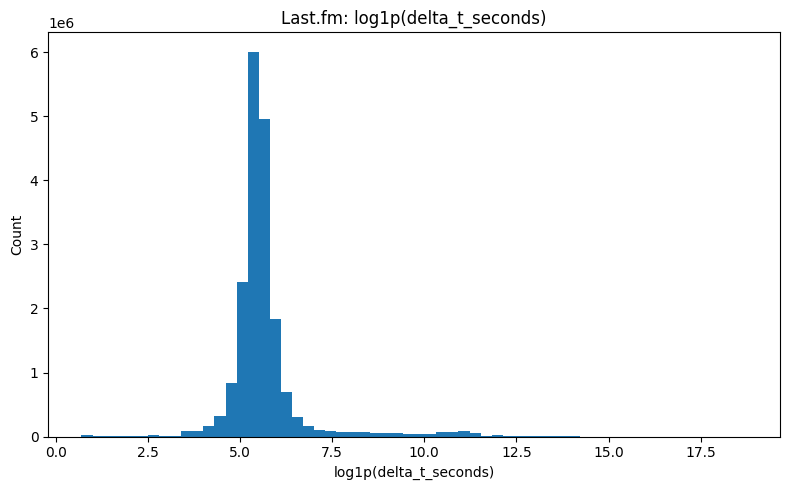

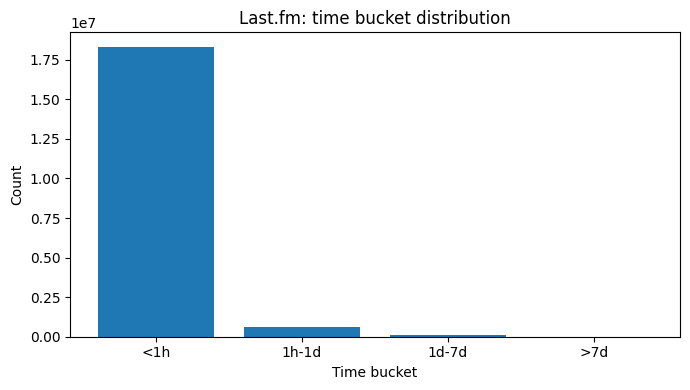

time_bucket
<1h      0.961097
1h-1d    0.033117
1d-7d    0.005272
>7d      0.000514
Name: share, dtype: float64

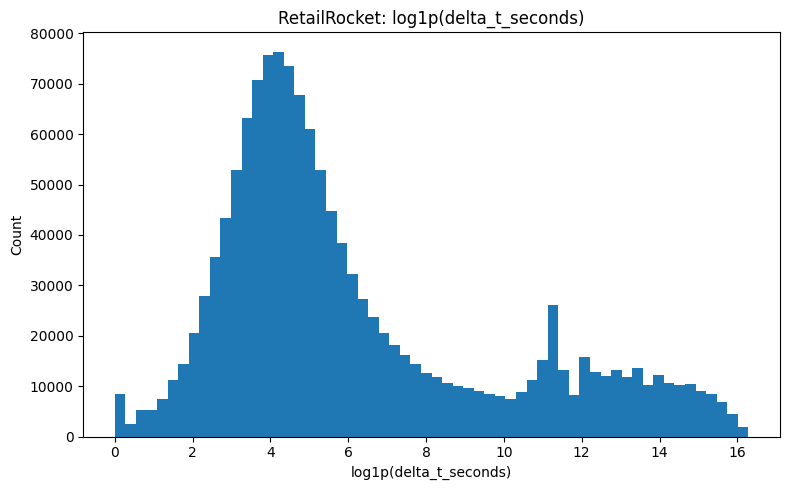

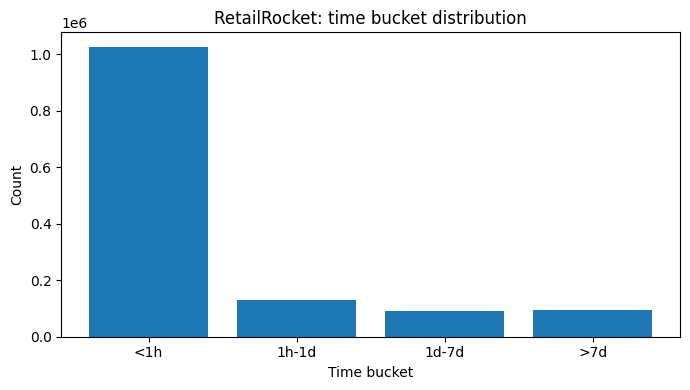

time_bucket
<1h      0.762802
1h-1d    0.096837
1d-7d    0.068983
>7d      0.071378
Name: share, dtype: float64

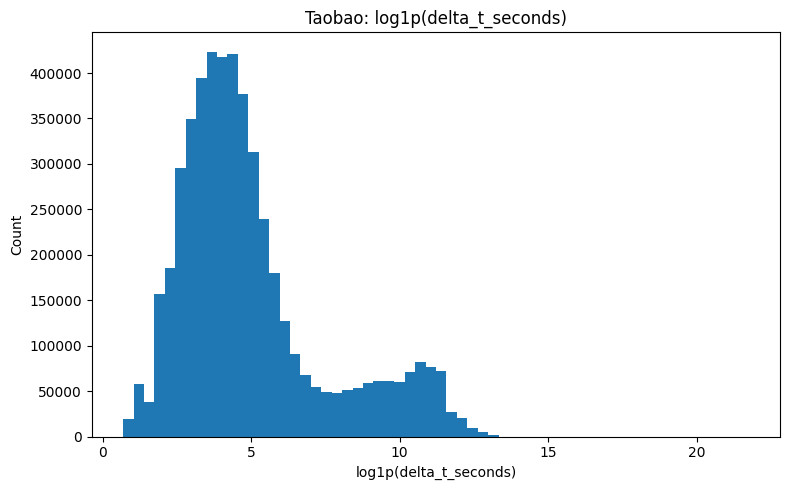

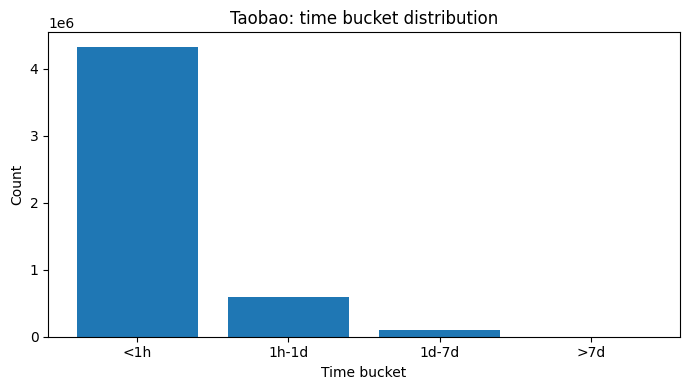

time_bucket
<1h      0.861972
1h-1d    0.118656
1d-7d    0.019350
>7d      0.000022
Name: share, dtype: float64

In [12]:
for name, targets in target_datasets.items():
    safe_name = name.lower().replace(".", "").replace(" ", "_")
    plot_log_delta_distribution(
        targets,
        name,
        FIGURE_DIR / f"{safe_name}_log_delta_distribution.png",
    )
    plot_time_bucket_distribution(
        targets,
        name,
        FIGURE_DIR / f"{safe_name}_time_bucket_distribution.png",
    )
    display(targets["time_bucket"].value_counts(normalize=True).reindex(TIME_BUCKET_LABELS, fill_value=0).rename("share"))


## 12. Phân tích hành vi sự kiện

Last.fm chỉ có một loại sự kiện `listen`, nên chuyển tiếp event gần như không mang nhiều thông tin. RetailRocket và Taobao có nhiều loại hành vi hơn, vì vậy `event_type` có thể là feature hữu ích cho bài toán next-time prediction.

Riêng Taobao, vì sequence-level analysis dùng subset trong khi full profile dùng chunk trên toàn bộ dataset, notebook so sánh phân phối hành vi giữa full data và subset. Nếu phân phối subset lệch nhiều so với full data, kết luận từ subset cần được diễn giải thận trọng và không được xem là full-data sequence analysis.


In [13]:
event_distribution_parts = []
transition_distribution_parts = []

taobao_sample_event_distribution = None
for name, df in sequence_datasets.items():
    scope = df["data_scope"].iloc[0]
    event_dist = compute_event_distribution(df, name, scope)
    event_distribution_parts.append(event_dist)
    transition_distribution_parts.append(compute_transition_distribution(target_datasets[name], name, scope, top_n=20))
    if name == "Taobao":
        taobao_sample_event_distribution = event_dist.copy()

if len(taobao_full_event_distribution):
    event_distribution_parts.append(taobao_full_event_distribution)

event_distribution_df = pd.concat(event_distribution_parts, ignore_index=True)
transition_distribution_df = pd.concat(transition_distribution_parts, ignore_index=True)

save_table(event_distribution_df, "event_distribution.csv")
save_table(transition_distribution_df, "transition_distribution.csv")

display(event_distribution_df)
display(transition_distribution_df)

if len(taobao_full_event_distribution) and taobao_sample_event_distribution is not None:
    full_dist = taobao_full_event_distribution.rename(columns={
        "count": "count_full",
        "percentage": "percentage_full",
    })[["dataset", "event_type", "count_full", "percentage_full"]]
    sample_dist = taobao_sample_event_distribution.rename(columns={
        "count": "count_sample",
        "percentage": "percentage_sample",
    })[["event_type", "count_sample", "percentage_sample"]]
    taobao_full_vs_sample_event_distribution = full_dist.merge(sample_dist, on="event_type", how="outer")
    taobao_full_vs_sample_event_distribution["dataset"] = "Taobao"
    taobao_full_vs_sample_event_distribution[["count_full", "count_sample"]] = taobao_full_vs_sample_event_distribution[["count_full", "count_sample"]].fillna(0).astype(int)
    taobao_full_vs_sample_event_distribution[["percentage_full", "percentage_sample"]] = taobao_full_vs_sample_event_distribution[["percentage_full", "percentage_sample"]].fillna(0)
    taobao_full_vs_sample_event_distribution["percentage_diff"] = (
        taobao_full_vs_sample_event_distribution["percentage_sample"]
        - taobao_full_vs_sample_event_distribution["percentage_full"]
    )
else:
    taobao_full_vs_sample_event_distribution = pd.DataFrame(columns=[
        "dataset", "event_type", "count_full", "percentage_full",
        "count_sample", "percentage_sample", "percentage_diff",
    ])

save_table(taobao_full_vs_sample_event_distribution, "taobao_full_vs_sample_event_distribution.csv")
display(taobao_full_vs_sample_event_distribution)


Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\event_distribution.csv
Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\transition_distribution.csv


,dataset,data_scope,event_type,count,percentage
0,Last.fm,full,listen,19098862,100.0
1,RetailRocket,full,view,2664312,96.669607
2,RetailRocket,full,addtocart,69332,2.515583
3,RetailRocket,full,transaction,22457,0.81481
4,Taobao,user_sample,pv,4558899,89.593888
5,Taobao,user_sample,cart,279956,5.501843
6,Taobao,user_sample,fav,147988,2.908338
7,Taobao,user_sample,buy,101561,1.99593
8,Taobao,full_chunk,pv,89716264,89.581169
9,Taobao,full_chunk,cart,5530446,5.522118


,dataset,data_scope,event_type,next_event_type,count,percentage
0,Last.fm,full,listen,listen,19055618,100.000000
1,RetailRocket,full,view,view,1219428,90.634479
2,RetailRocket,full,view,addtocart,51968,3.862543
3,RetailRocket,full,addtocart,view,31250,2.322669
4,RetailRocket,full,addtocart,transaction,12492,0.928473
5,RetailRocket,full,addtocart,addtocart,11186,0.831404
6,RetailRocket,full,transaction,view,11003,0.817802
7,RetailRocket,full,view,transaction,4988,0.370735
8,RetailRocket,full,transaction,transaction,2764,0.205435
9,RetailRocket,full,transaction,addtocart,356,0.026460


Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\taobao_full_vs_sample_event_distribution.csv


,dataset,event_type,count_full,percentage_full,count_sample,percentage_sample,percentage_diff
0,Taobao,buy,2015839,2.012804,101561,1.99593,-0.016873
1,Taobao,cart,5530446,5.522118,279956,5.501843,-0.020275
2,Taobao,fav,2888258,2.883909,147988,2.908338,0.024429
3,Taobao,pv,89716264,89.581169,4558899,89.593888,0.012719


## Phân tích hành vi sự kiện

Phần này phân tích phân phối `event_type` và các cặp chuyển tiếp `event_type -> next_event_type` trong từng dataset. Mục tiêu là kiểm tra xem loại hành vi có cung cấp thêm tín hiệu cho bài toán next-time prediction hay không. Nếu dataset chỉ có một loại event, mô hình gần như không học được sự khác biệt giữa các kiểu hành vi. Ngược lại, nếu dataset có nhiều loại event, `event_type` có thể được dùng như một feature để mô hình phân biệt các tình huống tương tác khác nhau.

Đối với Last.fm, toàn bộ dữ liệu chỉ có một loại event là `listen`, chiếm 100% số dòng. Vì vậy, chuyển tiếp event trong Last.fm luôn là `listen -> listen`. Điều này cho thấy `event_type` không mang nhiều thông tin phân biệt trong dataset này. Với Last.fm, tín hiệu quan trọng hơn nằm ở `user_id`, `item_id`, `timestamp`, lịch sử nghe nhạc và các đặc trưng thời gian như giờ trong ngày, ngày trong tuần hoặc khoảng cách giữa các lần nghe trước đó.

Đối với RetailRocket, dữ liệu có ba loại hành vi gồm `view`, `addtocart` và `transaction`. Tuy nhiên, phân phối event bị lệch rất mạnh về `view`, chiếm khoảng 96.67% toàn bộ event. `addtocart` chỉ chiếm khoảng 2.52%, còn `transaction` chỉ chiếm khoảng 0.81%. Điều này phản ánh đúng đặc điểm của dữ liệu thương mại điện tử: người dùng thường xem nhiều sản phẩm, nhưng số lần thêm vào giỏ và mua hàng ít hơn rất nhiều. Vì vậy, `event_type` là một feature hữu ích, nhưng các event quan trọng như `addtocart` và `transaction` bị thưa, khiến mô hình có thể khó học tốt nếu không xử lý mất cân bằng hành vi.

Bảng chuyển tiếp event của RetailRocket cho thấy phần lớn chuyển tiếp là `view -> view`, chiếm khoảng 90.63%. Điều này cho thấy đa số chuỗi tương tác là người dùng xem nhiều sản phẩm liên tiếp. Các chuyển tiếp có ý nghĩa mua sắm như `view -> addtocart`, `addtocart -> transaction` và `view -> transaction` xuất hiện ít hơn nhiều. Cụ thể, `view -> addtocart` chiếm khoảng 3.86%, `addtocart -> transaction` chiếm khoảng 0.93%, và `view -> transaction` chỉ chiếm khoảng 0.37%. Do đó, RetailRocket phù hợp với các bài toán purchase-aware hoặc conversion-aware, nhưng cần chú ý rằng tín hiệu mua hàng là tín hiệu hiếm.

Đối với Taobao user sample, dữ liệu có bốn loại hành vi gồm `pv`, `cart`, `fav` và `buy`. Trong đó, `pv` chiếm khoảng 89.59%, `cart` chiếm khoảng 5.50%, `fav` chiếm khoảng 2.91%, và `buy` chiếm khoảng 2.00%. Phân phối này cũng bị lệch về hành vi xem sản phẩm, nhưng ít cực đoan hơn RetailRocket vì tỷ lệ `buy` trong Taobao cao hơn tỷ lệ `transaction` trong RetailRocket. Điều này làm cho Taobao có tiềm năng tốt hơn để học các pattern hành vi mua sắm đa bước.

Bảng chuyển tiếp event của Taobao cho thấy chuyển tiếp phổ biến nhất là `pv -> pv`, chiếm khoảng 81.77%. Điều này phản ánh hành vi người dùng xem nhiều sản phẩm liên tiếp. Ngoài ra, các chuyển tiếp như `pv -> cart`, `cart -> pv`, `pv -> fav`, `fav -> pv`, `pv -> buy` và `buy -> pv` cũng xuất hiện với tỷ lệ đáng kể. Các chuyển tiếp này cho thấy Taobao không chỉ có chuỗi xem sản phẩm, mà còn có các hành vi thể hiện mức độ quan tâm cao hơn như thêm giỏ, yêu thích và mua hàng. Vì vậy, `event_type` trong Taobao có thể là feature quan trọng cho next-time prediction, đặc biệt nếu mô hình cần phân biệt giữa hành vi xem thông thường và hành vi gần với mua hàng.

Do Taobao sequence-level analysis được thực hiện trên `user_sample`, notebook cũng so sánh phân phối event giữa `full_chunk` và `user_sample`. Kết quả cho thấy phân phối sample gần như trùng với full data. Ví dụ, tỷ lệ `pv` trong full data là khoảng 89.58% và trong sample là khoảng 89.59%; tỷ lệ `cart` là khoảng 5.52% trong full data và 5.50% trong sample; tỷ lệ `fav` là khoảng 2.88% trong full data và 2.91% trong sample; tỷ lệ `buy` là khoảng 2.01% trong full data và 2.00% trong sample. Độ lệch giữa hai phân phối đều rất nhỏ, chỉ khoảng vài phần trăm điểm phần trăm hoặc thấp hơn.

Kết quả này cho thấy `user_sample` của Taobao tương đối đại diện cho full data về mặt phân phối hành vi. Vì vậy, các phân tích sequence trên subset có thể được xem là đáng tin cậy ở mức feasibility analysis. Tuy nhiên, vẫn cần diễn giải cẩn thận: kết luận này chỉ khẳng định sample gần full data về phân phối `event_type`, chưa khẳng định sample đại diện hoàn toàn về độ dài chuỗi, phân phối item, phân phối category hoặc phân phối timestamp.

Nhìn chung, phân tích event behavior cho thấy Last.fm phù hợp với next-time prediction dựa trên nhịp tương tác nghe nhạc, nhưng `event_type` không phải feature quan trọng vì chỉ có một loại event. RetailRocket và Taobao có nhiều loại hành vi hơn, nên `event_type` có thể đóng vai trò feature hữu ích để mô hình học khác biệt giữa các trạng thái tương tác. Tuy nhiên, cả hai dataset e-commerce đều bị lệch mạnh về hành vi xem sản phẩm, nên khi modeling cần chú ý đến mất cân bằng event và có thể cần thêm các target phụ như next action, will-buy hoặc time-to-buy.


## 13. Tính khả thi của temporal split

Random split nên được tránh vì có thể làm rò rỉ hành vi tương lai vào tập train. Leave-last-one split phù hợp hơn cho next-time prediction: mẫu target cuối cùng của mỗi user được dùng làm test, các mẫu trước đó dùng làm train. Nếu nhiều test user hoặc test item chưa từng xuất hiện trong train, bài toán mô hình hóa sẽ khó hơn.


In [14]:
split_parts = []
split_datasets = {}

for name, targets in target_datasets.items():
    train_df, test_df = leave_last_one_split(targets)
    split_datasets[name] = {"train": train_df, "test": test_df}
    scope = targets["data_scope"].iloc[0] if len(targets) else sequence_datasets[name]["data_scope"].iloc[0]
    split_parts.append(compute_split_stats(train_df, test_df, name, scope))

split_feasibility_df = pd.concat(split_parts, ignore_index=True)
save_table(split_feasibility_df, "split_feasibility.csv")
display(split_feasibility_df)


Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\split_feasibility.csv


,dataset,data_scope,train_samples,test_samples,train_users,test_users,test_users_seen_in_train,pct_test_users_seen_in_train,cold_start_item_rate
0,Last.fm,full,19054626,991,991,991,991,100.0,2.411874
1,RetailRocket,full,939469,199959,199959,199959,199959,100.0,9.896177
2,Taobao,user_sample,4970666,49989,49989,49989,49989,100.0,7.808518


### Nhận xét về temporal split và khả năng đánh giá mô hình

Bảng trên mô tả kết quả chia train/test theo hướng sequence-aware, trong đó mỗi user có đủ chuỗi sẽ được giữ lại phần lịch sử trước đó cho train và một phần event cuối cho test. Cách chia này phù hợp với bài toán next-time prediction vì mô hình phải dự đoán sự kiện tương lai dựa trên lịch sử quá khứ, thay vì trộn ngẫu nhiên các event làm rò rỉ thông tin thời gian.

Đối với Last.fm, tập train có 19,054,626 mẫu và tập test có 991 mẫu. Số lượng test nhỏ vì cách chia hiện tại gần với leave-one-out theo user, tức mỗi user đóng góp một mẫu test cuối cùng. Tất cả test user đều đã xuất hiện trong train, với `pct_test_users_seen_in_train = 100%`, nên đây không phải bài toán cold-start user. Điều này phù hợp với mục tiêu đánh giá next-time prediction trên user đã có lịch sử. Tuy nhiên, số test sample chỉ có 991 là khá nhỏ so với train, nên nếu dùng để đánh giá mô hình chính thức thì metric có thể chưa ổn định. Với Last.fm, có thể cân nhắc lấy nhiều hơn một event cuối của mỗi user làm test, ví dụ last 5% hoặc last N events, để có tập test lớn hơn.

Đối với RetailRocket, tập train có 939,469 mẫu và tập test có 199,959 mẫu. Đây là tỷ lệ test lớn hơn và hợp lý hơn so với Last.fm. Tất cả test user đều đã xuất hiện trong train, nghĩa là mô hình được đánh giá trên nhóm user có lịch sử tương tác trước đó. Điều này phù hợp với cách xử lý RetailRocket như một dataset short-sequence e-commerce, vì chỉ các user có đủ event mới tạo được mẫu train/test hợp lệ. Tuy nhiên, RetailRocket có `cold_start_item_rate` khoảng 9.90%, nghĩa là gần 10% item trong test chưa từng xuất hiện trong train. Đây là một hạn chế quan trọng vì các mô hình dựa trên embedding item có thể không học được biểu diễn cho các item này nếu không có cơ chế xử lý cold-start item.

Đối với Taobao user sample, tập train có 4,970,666 mẫu và tập test có 49,989 mẫu. Tất cả test user đều xuất hiện trong train, nên bài toán cũng là next-time prediction cho user đã có lịch sử. Quy mô test lớn hơn Last.fm và đủ để đánh giá mô hình ổn định hơn. Tuy nhiên, `cold_start_item_rate` khoảng 7.81%, cho thấy vẫn có một tỷ lệ item trong test chưa xuất hiện ở train. Vì vậy, khi modeling cần xử lý các item mới bằng cách ánh xạ về token `UNK`, dùng category-level feature, hoặc dùng mô hình không phụ thuộc hoàn toàn vào item embedding.

Nhìn chung, kết quả split cho thấy cả ba dataset đều có thể tạo được bài toán đánh giá next-time prediction hợp lệ theo hướng user-seen evaluation, vì 100% test user đều có lịch sử trong train. Điều này phù hợp với mục tiêu nghiên cứu hành vi tiếp theo của user đã quan sát trước đó, không phải bài toán cold-start user. Tuy nhiên, vẫn tồn tại cold-start item ở cả ba dataset, đặc biệt là RetailRocket và Taobao. Do đó, notebook modeling tiếp theo cần báo cáo rõ cách xử lý item chưa thấy trong train và không nên để mô hình truy cập thông tin item từ test trong quá trình huấn luyện.


## 14. Bảng so sánh feasibility cuối cùng

Bảng cuối cùng được suy ra từ các chỉ báo đã tính, thay vì gán nhãn hoàn toàn thủ công. Các nhãn `sequence_quality`, `timestamp_quality`, và `target_quality` được tính từ thống kê sequence, tỷ lệ thiếu `timestamp`, và số lượng mẫu next-time hợp lệ. Với Taobao, kết luận luôn ghi rõ yêu cầu chunking/sampling khi sequence-level analysis không chạy trên full data.


In [15]:
def label_sequence_quality(row):
    if row["pct_users_with_5plus"] >= 50:
        return "Strong"
    if row["pct_users_with_2plus"] >= 50:
        return "Medium"
    return "Weak"


def label_target_quality(row):
    if row["num_next_time_samples"] >= 1_000_000:
        return "Strong"
    if row["num_next_time_samples"] >= 100_000:
        return "Medium"
    return "Weak"


def label_timestamp_quality(row):
    if row["missing_timestamp_rate"] == 0:
        return "Strong"
    if row["missing_timestamp_rate"] < 0.01:
        return "Medium"
    return "Weak"


def derive_final_feasibility(row):
    if row["sequence_quality"] == "Weak" or row["target_quality"] == "Weak":
        return "Weak"
    if row["dataset"] == "Taobao" and row["target_quality"] != "Weak":
        return "Strong but requires sampling/chunking"
    if row["sequence_quality"] == "Strong" and row["target_quality"] == "Strong" and row["timestamp_quality"] != "Weak":
        return "Strong"
    return "Medium"


sequence_quality_df = sequence_stats_df.copy()
sequence_quality_df["sequence_quality"] = sequence_quality_df.apply(label_sequence_quality, axis=1)

target_quality_df = delta_time_stats_df.copy()
target_quality_df["target_quality"] = target_quality_df.apply(label_target_quality, axis=1)

timestamp_quality_df = basic_stats_df[basic_stats_df["data_scope"].isin(sequence_stats_df["data_scope"])].copy()
timestamp_quality_df = timestamp_quality_df.sort_values(["dataset", "data_scope"]).drop_duplicates(["dataset", "data_scope"], keep="last")
timestamp_quality_df["timestamp_quality"] = timestamp_quality_df.apply(label_timestamp_quality, axis=1)

final_base = (
    sequence_quality_df[["dataset", "data_scope", "sequence_quality"]]
    .merge(timestamp_quality_df[["dataset", "data_scope", "timestamp_quality"]], on=["dataset", "data_scope"], how="left")
    .merge(target_quality_df[["dataset", "data_scope", "target_quality"]], on=["dataset", "data_scope"], how="left")
    .merge(target_type_recommendation_df[["dataset", "data_scope", "recommended_target_type"]], on=["dataset", "data_scope"], how="left")
)

full_profile_available_map = {
    "Last.fm": True,
    "RetailRocket": True,
    "Taobao": bool(len(taobao_full_basic_stats)),
}
event_signal_quality_map = {
    "Last.fm": "Simple",
    "RetailRocket": "Strong",
    "Taobao": "Strong",
}
scalability_issue_map = {
    "Last.fm": "Low",
    "RetailRocket": "Low",
    "Taobao": "High; requires chunking or sampling",
}
recommended_modeling_use_map = {
    "Last.fm": "primary dataset for temporal consumption next-time prediction",
    "RetailRocket": "second dataset for e-commerce event-time prediction",
    "Taobao": "scalability and robustness dataset",
}

final_feasibility_table = final_base.rename(columns={"data_scope": "sequence_data_scope"})
final_feasibility_table["full_profile_available"] = final_feasibility_table["dataset"].map(full_profile_available_map)
final_feasibility_table["event_signal_quality"] = final_feasibility_table["dataset"].map(event_signal_quality_map)
final_feasibility_table["scalability_issue"] = final_feasibility_table["dataset"].map(scalability_issue_map)
final_feasibility_table["recommended_target"] = final_feasibility_table["recommended_target_type"]
final_feasibility_table["recommended_modeling_use"] = final_feasibility_table["dataset"].map(recommended_modeling_use_map)
final_feasibility_table["final_feasibility"] = final_feasibility_table.apply(derive_final_feasibility, axis=1)

final_feasibility_table = final_feasibility_table[[
    "dataset",
    "sequence_data_scope",
    "full_profile_available",
    "sequence_quality",
    "timestamp_quality",
    "target_quality",
    "event_signal_quality",
    "scalability_issue",
    "recommended_target",
    "recommended_modeling_use",
    "final_feasibility",
]]

save_table(final_feasibility_table, "final_feasibility_table.csv")
display(final_feasibility_table)


Saved: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\final_feasibility_table.csv


,dataset,sequence_data_scope,full_profile_available,sequence_quality,timestamp_quality,target_quality,event_signal_quality,scalability_issue,recommended_target,recommended_modeling_use,final_feasibility
0,Last.fm,full,True,Strong,Strong,Strong,Simple,Low,log_delta_regression,primary dataset for temporal consumption next-...,Strong
1,RetailRocket,full,True,Weak,Strong,Strong,Strong,Low,time_bucket_classification,second dataset for e-commerce event-time predi...,Weak
2,Taobao,user_sample,True,Strong,Strong,Strong,Strong,High; requires chunking or sampling,time_bucket_classification,scalability and robustness dataset,Strong but requires sampling/chunking


## 15. Kết luận

Notebook này tập trung vào next-time prediction, không phải EDA tổng quát và không huấn luyện mô hình. Last.fm, RetailRocket, và Taobao được chuẩn hóa về schema chung gồm `user_id`, `item_id`, `event_type`, và `timestamp`.

Last.fm và RetailRocket phù hợp cho phân tích feasibility full-data đối với bài toán dự đoán thời gian đến sự kiện tiếp theo. Taobao cũng phù hợp như một dataset lớn, đa hành vi, nhưng cần chunking/sampling để xử lý thực tế trên máy cá nhân. Với Taobao, profile toàn bộ và phân tích sequence-level là hai phạm vi khác nhau; các kết luận sequence-level chỉ nên được hiểu ở mức subset nếu notebook không chạy full sequence analysis.

Target chung của bài toán là `delta_t_seconds`. Do phân phối target thường lệch mạnh, notebook mô hình tiếp theo nên bắt đầu với `time_bucket` classification hoặc hồi quy trên `log1p(delta_t_seconds)`.

Thứ tự mô hình hóa được khuyến nghị:

1. Last.fm trước.
2. RetailRocket thứ hai.
3. Taobao subset thứ ba để kiểm tra scalability và robustness.

Notebook này không thêm model training, không tuning hyperparameter, và không triển khai deep learning model. Mục tiêu duy nhất là chuẩn bị và biện minh cho giai đoạn mô hình hóa tiếp theo.
